In [1]:
# ==========================================
# HealthAI StressTest
# Crash Test 0: Baseline Model
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

print("HealthAI StressTest initialized.")

HealthAI StressTest initialized.


In [2]:
# Download official MEPS 2024 HC-256 dataset

!wget -q https://meps.ahrq.gov/data_files/pufs/h256/h256v9.zip -O h256v9.zip

# Unzip
!unzip -q -o h256v9.zip -d meps2024

# Show downloaded files
!find meps2024 -type f

meps2024/h256.sas7bdat


In [3]:
# Load MEPS 2024 dataset

file_path = "/content/meps2024/h256.sas7bdat"

df = pd.read_sas(
    file_path,
    format="sas7bdat",
    encoding="latin-1"
)

# Standardize column names
df.columns = df.columns.str.upper()

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (19140, 1615)


,DUID,PID,DUPERSID,PANEL,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID24,FAMIDYR,...,RXOTH24,PERWT24F,FAMWT24F,FAMWT24C,VARSTR,VARPSU,SAQWT24F,CSAQW24F,ESAQWT24F,PESAQWT24F
0,2810003.0,101.0,2810003101,28.0,2024.0,A,A,A,A,A,...,0.0,16532.179401,14481.891794,14481.891794,2062.0,1.0,19220.259043,0.0,19419.845142,22951.575300
1,2810006.0,101.0,2810006101,28.0,2024.0,A,A,A,A,A,...,0.0,41818.011780,44596.922708,44596.922708,2012.0,1.0,56091.114785,0.0,53136.862856,55108.036888
2,2810006.0,102.0,2810006102,28.0,2024.0,A,A,A,A,A,...,0.0,31330.068633,44596.922708,44596.922708,2012.0,1.0,48905.537993,0.0,53953.868356,56373.565367
3,2810006.0,103.0,2810006103,28.0,2024.0,A,A,A,A,A,...,0.0,47067.704703,44596.922708,44596.922708,2012.0,1.0,0.000000,0.0,0.000000,0.000000
4,2810006.0,104.0,2810006104,28.0,2024.0,A,A,A,A,A,...,0.0,33240.146510,44596.922708,44596.922708,2012.0,1.0,64420.763838,0.0,86534.512832,77577.353499


In [4]:
variables = [
    "DUPERSID",
    "AGE24X",
    "SEX",
    "RACETHX",
    "POVCAT24",
    "EDUCYR",
    "INSCOV24",
    "RTHLTH53",
    "MNHLTH53",
    "HIBPDX",
    "DIABDX_M18",
    "TOTEXP24",
    "PERWT24F",
    "VARSTR",
    "VARPSU"
]

missing_vars = [v for v in variables if v not in df.columns]

print("Missing variables:", missing_vars)

healthai = df[variables].copy()

print("Starting sample:", len(healthai))

healthai.head()

Missing variables: []
Starting sample: 19140


,DUPERSID,AGE24X,SEX,RACETHX,POVCAT24,EDUCYR,INSCOV24,RTHLTH53,MNHLTH53,HIBPDX,DIABDX_M18,TOTEXP24,PERWT24F,VARSTR,VARPSU
0,2810003101,67.0,2.0,2.0,5.0,12.0,2.0,3.0,4.0,2.0,2.0,12912.0,16532.179401,2062.0,1.0
1,2810006101,47.0,2.0,3.0,5.0,16.0,1.0,1.0,2.0,2.0,2.0,875.0,41818.011780,2012.0,1.0
2,2810006102,51.0,1.0,3.0,5.0,13.0,1.0,2.0,2.0,2.0,2.0,0.0,31330.068633,2012.0,1.0
3,2810006103,14.0,2.0,3.0,5.0,5.0,1.0,1.0,1.0,-1.0,2.0,3665.0,47067.704703,2012.0,1.0
4,2810006104,20.0,1.0,3.0,5.0,11.0,1.0,1.0,2.0,2.0,2.0,282.0,33240.146510,2012.0,1.0


In [5]:
# Keep adults age 18+ with valid survey weights

healthai = healthai[
    (healthai["AGE24X"] >= 18) &
    (healthai["PERWT24F"] > 0)
].copy()

# Keep valid categories for baseline predictors
healthai = healthai[
    healthai["SEX"].isin([1, 2]) &
    healthai["RACETHX"].isin([1, 2, 3, 4, 5]) &
    healthai["POVCAT24"].isin([1, 2, 3, 4, 5]) &
    healthai["EDUCYR"].between(0, 17) &
    healthai["INSCOV24"].isin([1, 2, 3]) &
    healthai["RTHLTH53"].isin([1, 2, 3, 4, 5]) &
    healthai["MNHLTH53"].isin([1, 2, 3, 4, 5]) &
    healthai["HIBPDX"].isin([1, 2]) &
    healthai["DIABDX_M18"].isin([1, 2]) &
    (healthai["TOTEXP24"] >= 0)
].copy()

# Convert chronic disease variables to binary 0/1
healthai["HYPERTENSION"] = (healthai["HIBPDX"] == 1).astype(int)
healthai["DIABETES"] = (healthai["DIABDX_M18"] == 1).astype(int)

print("Final adult analytic sample:", len(healthai))

print("\nRace/ethnicity counts:")
print(healthai["RACETHX"].value_counts().sort_index())

Final adult analytic sample: 14666

Race/ethnicity counts:
RACETHX
1.0    2806
2.0    8741
3.0    1833
4.0     834
5.0     452
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

# ==========================================
# Crash Test 0
# Train/Test Split
# ==========================================

train, test = train_test_split(
    healthai,
    test_size=0.30,
    random_state=42,
    stratify=healthai["RACETHX"]
)

print("Training sample:", len(train))
print("Testing sample:", len(test))

print("\nTraining race distribution:")
print(train["RACETHX"].value_counts().sort_index())

print("\nTesting race distribution:")
print(test["RACETHX"].value_counts().sort_index())

Training sample: 10266
Testing sample: 4400

Training race distribution:
RACETHX
1.0    1964
2.0    6119
3.0    1283
4.0     584
5.0     316
Name: count, dtype: int64

Testing race distribution:
RACETHX
1.0     842
2.0    2622
3.0     550
4.0     250
5.0     136
Name: count, dtype: int64


In [7]:
# ==========================================
# Define High Healthcare Spending
# Weighted top 20% using TRAINING data only
# ==========================================

import numpy as np

def weighted_quantile(values, weights, quantile):
    values = np.asarray(values)
    weights = np.asarray(weights)

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]

    cumulative_weights = np.cumsum(weights)
    cutoff = quantile * cumulative_weights[-1]

    return values[np.searchsorted(cumulative_weights, cutoff)]


high_cost_cutoff = weighted_quantile(
    train["TOTEXP24"],
    train["PERWT24F"],
    0.80
)

print(f"High-cost expenditure threshold: ${high_cost_cutoff:,.2f}")


# Create binary outcome
train["HIGH_COST"] = (
    train["TOTEXP24"] >= high_cost_cutoff
).astype(int)

test["HIGH_COST"] = (
    test["TOTEXP24"] >= high_cost_cutoff
).astype(int)


print("\nUnweighted training outcome:")
print(train["HIGH_COST"].value_counts())
print(train["HIGH_COST"].value_counts(normalize=True).round(3))

print("\nUnweighted testing outcome:")
print(test["HIGH_COST"].value_counts())
print(test["HIGH_COST"].value_counts(normalize=True).round(3))


# Weighted prevalence
train_weighted_rate = np.average(
    train["HIGH_COST"],
    weights=train["PERWT24F"]
)

test_weighted_rate = np.average(
    test["HIGH_COST"],
    weights=test["PERWT24F"]
)

print(
    f"\nWeighted training high-cost rate: "
    f"{train_weighted_rate:.1%}"
)

print(
    f"Weighted testing high-cost rate: "
    f"{test_weighted_rate:.1%}"
)

High-cost expenditure threshold: $11,223.00

Unweighted training outcome:
HIGH_COST
0    7936
1    2330
Name: count, dtype: int64
HIGH_COST
0    0.773
1    0.227
Name: proportion, dtype: float64

Unweighted testing outcome:
HIGH_COST
0    3388
1    1012
Name: count, dtype: int64
HIGH_COST
0    0.77
1    0.23
Name: proportion, dtype: float64

Weighted training high-cost rate: 20.0%
Weighted testing high-cost rate: 20.6%


In [8]:
# ==========================================
# Crash Test 0
# Baseline Logistic Regression Model
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Race is intentionally NOT included as a predictor.
# We will use RACETHX only for subgroup equity auditing.

features = [
    "AGE24X",
    "SEX",
    "POVCAT24",
    "EDUCYR",
    "INSCOV24",
    "RTHLTH53",
    "MNHLTH53",
    "HYPERTENSION",
    "DIABETES"
]

numeric_features = [
    "AGE24X",
    "EDUCYR"
]

categorical_features = [
    "SEX",
    "POVCAT24",
    "INSCOV24",
    "RTHLTH53",
    "MNHLTH53",
    "HYPERTENSION",
    "DIABETES"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

baseline_model.fit(
    train[features],
    train["HIGH_COST"],
    model__sample_weight=train["PERWT24F"]
)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [9]:
# ==========================================
# Baseline AUC
# ==========================================

from sklearn.metrics import roc_auc_score

train["PRED_PROB"] = baseline_model.predict_proba(
    train[features]
)[:, 1]

test["PRED_PROB"] = baseline_model.predict_proba(
    test[features]
)[:, 1]

train_auc = roc_auc_score(
    train["HIGH_COST"],
    train["PRED_PROB"],
    sample_weight=train["PERWT24F"]
)

test_auc = roc_auc_score(
    test["HIGH_COST"],
    test["PRED_PROB"],
    sample_weight=test["PERWT24F"]
)

print(f"Weighted training AUC: {train_auc:.3f}")
print(f"Weighted testing AUC:  {test_auc:.3f}")

Weighted training AUC: 0.777
Weighted testing AUC:  0.760


In [10]:
# ==========================================
# Choose Classification Threshold
# Using TRAINING data only
# ==========================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    train["HIGH_COST"],
    train["PRED_PROB"],
    sample_weight=train["PERWT24F"]
)

# Youden's J = Sensitivity - False Positive Rate
youden_j = tpr - fpr

best_index = np.argmax(youden_j)

decision_threshold = thresholds[best_index]

print(
    f"Optimal classification threshold: "
    f"{decision_threshold:.3f}"
)

Optimal classification threshold: 0.179


In [11]:
# Apply frozen threshold to TEST data

test["PRED_CLASS"] = (
    test["PRED_PROB"] >= decision_threshold
).astype(int)

print(test["PRED_CLASS"].value_counts())

PRED_CLASS
1    2294
0    2106
Name: count, dtype: int64


In [13]:
# ==========================================
# Equity Audit Metric Function
# ==========================================

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix
)

def calculate_metrics(data):

    y_true = data["HIGH_COST"]
    y_prob = data["PRED_PROB"]
    y_pred = data["PRED_CLASS"]
    weights = data["PERWT24F"]

    # AUC
    auc = roc_auc_score(
        y_true,
        y_prob,
        sample_weight=weights
    )

    # Weighted confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
        sample_weight=weights
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp)
    fnr = fn / (fn + tp)

    # Calibration summary
    observed_rate = np.average(
        y_true,
        weights=weights
    )

    predicted_rate = np.average(
        y_prob,
        weights=weights
    )

    calibration_gap = abs(
        predicted_rate - observed_rate
    )

    # Brier score
    brier = np.average(
        (y_prob - y_true) ** 2,
        weights=weights
    )

    return {
        "N": len(data),
        "AUC": auc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "FNR": fnr,
        "Observed_Rate": observed_rate,
        "Predicted_Rate": predicted_rate,
        "Calibration_Gap": calibration_gap,
        "Brier": brier
    }

In [14]:
# ==========================================
# Crash Test 0 Equity Audit
# ==========================================

race_labels = {
    1: "Hispanic",
    2: "NH White",
    3: "NH Black",
    4: "NH Asian",
    5: "NH Other/Multiple"
}

results = []

# Overall
overall_metrics = calculate_metrics(test)
overall_metrics["Group"] = "Overall"
results.append(overall_metrics)

# Race/ethnicity groups
for code, label in race_labels.items():

    subgroup = test[
        test["RACETHX"] == code
    ]

    metrics = calculate_metrics(subgroup)
    metrics["Group"] = label

    results.append(metrics)


baseline_results = pd.DataFrame(results)

baseline_results = baseline_results[
    [
        "Group",
        "N",
        "AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "FNR",
        "Observed_Rate",
        "Predicted_Rate",
        "Calibration_Gap",
        "Brier"
    ]
]

baseline_results.round(3)

,Group,N,AUC,Sensitivity,Specificity,PPV,FNR,Observed_Rate,Predicted_Rate,Calibration_Gap,Brier
0,Overall,4400,0.760,0.746,0.640,0.350,0.254,0.206,0.207,0.001,0.139
1,Hispanic,842,0.783,0.675,0.769,0.322,0.325,0.140,0.157,0.018,0.106
2,NH White,2622,0.741,0.758,0.591,0.383,0.242,0.251,0.224,0.027,0.161
3,NH Black,550,0.834,0.872,0.650,0.308,0.128,0.152,0.209,0.058,0.102
4,NH Asian,250,0.645,0.520,0.639,0.147,0.480,0.107,0.197,0.090,0.112
5,NH Other/Multiple,136,0.764,0.628,0.666,0.296,0.372,0.183,0.197,0.014,0.127


In [15]:
# ==========================================
# Crash Test Pipeline
# Allows controlled missingness
# ==========================================

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

stress_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

def create_model():

    return Pipeline(
        steps=[
            ("preprocessor", stress_preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    random_state=42
                )
            )
        ]
    )

print("Stress-test pipeline ready.")

Stress-test pipeline ready.


In [16]:
# ==========================================
# CRASH TEST 1
# Selective Poverty Data Missingness
# ==========================================

missingness_levels = [
    0.00,
    0.10,
    0.25,
    0.50,
    0.75,
    1.00
]

crash1_results = []

for level in missingness_levels:

    # Fresh copy every experiment
    degraded_train = train.copy()

    # Identify lower-income participants
    low_income_indices = degraded_train[
        degraded_train["POVCAT24"].isin([1, 2])
    ].index

    # Randomly choose participants whose poverty data disappear
    rng = np.random.RandomState(42)

    n_remove = int(
        len(low_income_indices) * level
    )

    if n_remove > 0:

        remove_indices = rng.choice(
            low_income_indices,
            size=n_remove,
            replace=False
        )

        degraded_train.loc[
            remove_indices,
            "POVCAT24"
        ] = np.nan

    # Create and train fresh model
    crash_model = create_model()

    crash_model.fit(
        degraded_train[features],
        degraded_train["HIGH_COST"],
        model__sample_weight=degraded_train["PERWT24F"]
    )

    # Use SAME untouched test population
    temp_test = test.copy()

    temp_test["PRED_PROB"] = (
        crash_model.predict_proba(
            temp_test[features]
        )[:, 1]
    )

    # Freeze original baseline threshold
    temp_test["PRED_CLASS"] = (
        temp_test["PRED_PROB"]
        >= decision_threshold
    ).astype(int)

    # Overall metrics
    overall_metrics = calculate_metrics(
        temp_test
    )

    overall_metrics["Group"] = "Overall"
    overall_metrics["Missingness"] = level

    crash1_results.append(
        overall_metrics
    )

    # Race subgroup metrics
    for code, label in race_labels.items():

        subgroup = temp_test[
            temp_test["RACETHX"] == code
        ]

        metrics = calculate_metrics(
            subgroup
        )

        metrics["Group"] = label
        metrics["Missingness"] = level

        crash1_results.append(
            metrics
        )


crash1_results = pd.DataFrame(
    crash1_results
)

print("Crash Test 1 completed.")

Crash Test 1 completed.


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [17]:
crash1_summary = crash1_results[
    [
        "Missingness",
        "Group",
        "AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "FNR",
        "Calibration_Gap"
    ]
].copy()

crash1_summary[
    [
        "AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "FNR",
        "Calibration_Gap"
    ]
] = crash1_summary[
    [
        "AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "FNR",
        "Calibration_Gap"
    ]
].round(3)

crash1_summary

,Missingness,Group,AUC,Sensitivity,Specificity,PPV,FNR,Calibration_Gap
0,0.00,Overall,0.760,0.746,0.640,0.350,0.254,0.001
1,0.00,Hispanic,0.783,0.675,0.769,0.322,0.325,0.018
2,0.00,NH White,0.741,0.758,0.591,0.383,0.242,0.027
3,0.00,NH Black,0.834,0.872,0.650,0.308,0.128,0.058
4,0.00,NH Asian,0.645,0.520,0.639,0.147,0.480,0.090
5,0.00,NH Other/Multiple,0.764,0.628,0.666,0.296,0.372,0.014
6,0.10,Overall,0.760,0.746,0.641,0.351,0.254,0.000
7,0.10,Hispanic,0.784,0.675,0.773,0.325,0.325,0.017
8,0.10,NH White,0.741,0.758,0.593,0.384,0.242,0.028
9,0.10,NH Black,0.834,0.872,0.645,0.305,0.128,0.058


In [18]:
# Focus on false-negative rates

fnr_table = crash1_summary.pivot(
    index="Missingness",
    columns="Group",
    values="FNR"
)

fnr_table

Group,Hispanic,NH Asian,NH Black,NH Other/Multiple,NH White,Overall
Missingness,,,,,,
0.00,0.325,0.48,0.128,0.372,0.242,0.254
0.10,0.325,0.48,0.128,0.372,0.242,0.254
0.25,0.325,0.48,0.128,0.372,0.242,0.254
0.50,0.325,0.48,0.128,0.372,0.242,0.254
0.75,0.325,0.48,0.128,0.372,0.247,0.258
1.00,0.325,0.48,0.129,0.372,0.253,0.263


In [19]:
# ==========================================
# Define socioeconomic audit groups
# TEST DATA REMAINS UNCHANGED
# ==========================================

test["Income_Group"] = np.where(
    test["POVCAT24"].isin([1, 2]),
    "Lower income",
    "Higher income"
)

print(test["Income_Group"].value_counts())

Income_Group
Higher income    3599
Lower income      801
Name: count, dtype: int64


In [20]:
# ==========================================
# CRASH TEST 1B
# Add socioeconomic subgroup audit
# ==========================================

crash1_income_results = []

for level in missingness_levels:

    degraded_train = train.copy()

    low_income_indices = degraded_train[
        degraded_train["POVCAT24"].isin([1, 2])
    ].index

    rng = np.random.RandomState(42)

    n_remove = int(
        len(low_income_indices) * level
    )

    if n_remove > 0:

        remove_indices = rng.choice(
            low_income_indices,
            size=n_remove,
            replace=False
        )

        degraded_train.loc[
            remove_indices,
            "POVCAT24"
        ] = np.nan

    crash_model = create_model()

    crash_model.fit(
        degraded_train[features],
        degraded_train["HIGH_COST"],
        model__sample_weight=degraded_train["PERWT24F"]
    )

    temp_test = test.copy()

    temp_test["PRED_PROB"] = (
        crash_model.predict_proba(
            temp_test[features]
        )[:, 1]
    )

    temp_test["PRED_CLASS"] = (
        temp_test["PRED_PROB"] >= decision_threshold
    ).astype(int)

    for group in ["Lower income", "Higher income"]:

        subgroup = temp_test[
            temp_test["Income_Group"] == group
        ]

        metrics = calculate_metrics(subgroup)

        metrics["Income_Group"] = group
        metrics["Missingness"] = level

        crash1_income_results.append(metrics)


crash1_income_results = pd.DataFrame(
    crash1_income_results
)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [21]:
income_fnr_table = crash1_income_results.pivot(
    index="Missingness",
    columns="Income_Group",
    values="FNR"
)

income_fnr_table.round(3)

Income_Group,Higher income,Lower income
Missingness,,
0.00,0.252,0.265
0.10,0.252,0.265
0.25,0.253,0.259
0.50,0.253,0.259
0.75,0.258,0.259
1.00,0.258,0.292


In [22]:
# ==========================================
# CRASH TEST 2
# NH Asian Underrepresentation
# ==========================================

representation_levels = [
    1.00,   # keep 100%
    0.75,   # keep 75%
    0.50,   # keep 50%
    0.25,   # keep 25%
    0.10    # keep 10%
]

crash2_results = []

# NH Asian = RACETHX 4
target_group = 4

for level in representation_levels:

    degraded_train = train.copy()

    asian_indices = degraded_train[
        degraded_train["RACETHX"] == target_group
    ].index

    other_indices = degraded_train[
        degraded_train["RACETHX"] != target_group
    ].index

    # Number of NH Asian participants to retain
    n_keep = int(len(asian_indices) * level)

    rng = np.random.RandomState(42)

    keep_asian = rng.choice(
        asian_indices,
        size=n_keep,
        replace=False
    )

    # Keep all other groups + selected Asian participants
    keep_indices = list(other_indices) + list(keep_asian)

    degraded_train = degraded_train.loc[
        keep_indices
    ].copy()

    # Train fresh model
    crash_model = create_model()

    crash_model.fit(
        degraded_train[features],
        degraded_train["HIGH_COST"],
        model__sample_weight=degraded_train["PERWT24F"]
    )

    # Untouched test set
    temp_test = test.copy()

    temp_test["PRED_PROB"] = (
        crash_model.predict_proba(
            temp_test[features]
        )[:, 1]
    )

    # Keep original baseline threshold frozen
    temp_test["PRED_CLASS"] = (
        temp_test["PRED_PROB"] >= decision_threshold
    ).astype(int)

    # Overall
    overall_metrics = calculate_metrics(temp_test)

    overall_metrics["Group"] = "Overall"
    overall_metrics["Representation"] = level
    overall_metrics["Training_N"] = len(degraded_train)

    crash2_results.append(overall_metrics)

    # Race groups
    for code, label in race_labels.items():

        subgroup = temp_test[
            temp_test["RACETHX"] == code
        ]

        metrics = calculate_metrics(subgroup)

        metrics["Group"] = label
        metrics["Representation"] = level
        metrics["Training_N"] = len(degraded_train)

        crash2_results.append(metrics)


crash2_results = pd.DataFrame(crash2_results)

print("Crash Test 2 completed.")

Crash Test 2 completed.


In [23]:
asian_crash2 = crash2_results[
    crash2_results["Group"].isin(
        ["Overall", "NH Asian"]
    )
][
    [
        "Representation",
        "Group",
        "AUC",
        "Sensitivity",
        "FNR",
        "Calibration_Gap"
    ]
]

asian_crash2.round(3)

,Representation,Group,AUC,Sensitivity,FNR,Calibration_Gap
0,1.00,Overall,0.760,0.746,0.254,0.001
4,1.00,NH Asian,0.645,0.520,0.480,0.090
6,0.75,Overall,0.760,0.749,0.251,0.002
10,0.75,NH Asian,0.645,0.520,0.480,0.092
12,0.50,Overall,0.760,0.751,0.249,0.004
16,0.50,NH Asian,0.644,0.520,0.480,0.094
18,0.25,Overall,0.759,0.755,0.245,0.005
22,0.25,NH Asian,0.644,0.520,0.480,0.095
24,0.10,Overall,0.759,0.761,0.239,0.006
28,0.10,NH Asian,0.643,0.520,0.480,0.097


In [24]:
crash2_fnr = crash2_results.pivot(
    index="Representation",
    columns="Group",
    values="FNR"
)

crash2_fnr.round(3)

Group,Hispanic,NH Asian,NH Black,NH Other/Multiple,NH White,Overall
Representation,,,,,,
0.10,0.313,0.48,0.117,0.341,0.226,0.239
0.25,0.313,0.48,0.117,0.341,0.234,0.245
0.50,0.325,0.48,0.128,0.372,0.234,0.249
0.75,0.325,0.48,0.128,0.372,0.237,0.251
1.00,0.325,0.48,0.128,0.372,0.242,0.254


In [25]:
# ==========================================
# CRASH TEST 3
# Measurement Error in Self-Rated Health
# ==========================================

error_levels = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40
]

crash3_results = []

for level in error_levels:

    degraded_train = train.copy()

    rng = np.random.RandomState(42)

    n_corrupt = int(
        len(degraded_train) * level
    )

    if n_corrupt > 0:

        corrupt_indices = rng.choice(
            degraded_train.index,
            size=n_corrupt,
            replace=False
        )

        for idx in corrupt_indices:

            original = degraded_train.loc[
                idx,
                "RTHLTH53"
            ]

            # Introduce a plausible +/- 1 category error
            if original == 1:
                new_value = 2

            elif original == 5:
                new_value = 4

            else:
                shift = rng.choice([-1, 1])
                new_value = original + shift

            degraded_train.loc[
                idx,
                "RTHLTH53"
            ] = new_value

    # Train a fresh model
    crash_model = create_model()

    crash_model.fit(
        degraded_train[features],
        degraded_train["HIGH_COST"],
        model__sample_weight=degraded_train["PERWT24F"]
    )

    # Untouched test data
    temp_test = test.copy()

    temp_test["PRED_PROB"] = (
        crash_model.predict_proba(
            temp_test[features]
        )[:, 1]
    )

    # Keep baseline threshold frozen
    temp_test["PRED_CLASS"] = (
        temp_test["PRED_PROB"]
        >= decision_threshold
    ).astype(int)

    # Overall results
    overall_metrics = calculate_metrics(
        temp_test
    )

    overall_metrics["Group"] = "Overall"
    overall_metrics["Error_Level"] = level

    crash3_results.append(
        overall_metrics
    )

    # Race/ethnicity results
    for code, label in race_labels.items():

        subgroup = temp_test[
            temp_test["RACETHX"] == code
        ]

        metrics = calculate_metrics(
            subgroup
        )

        metrics["Group"] = label
        metrics["Error_Level"] = level

        crash3_results.append(
            metrics
        )


crash3_results = pd.DataFrame(
    crash3_results
)

print("Crash Test 3 completed.")

Crash Test 3 completed.


In [26]:
crash3_small = crash3_results[
    [
        "Error_Level",
        "Group",
        "AUC",
        "Sensitivity",
        "FNR",
        "Calibration_Gap"
    ]
]

crash3_small[
    crash3_small["Group"].isin(
        ["Overall", "Hispanic", "NH White",
         "NH Black", "NH Asian"]
    )
].round(3)

,Error_Level,Group,AUC,Sensitivity,FNR,Calibration_Gap
0,0.00,Overall,0.760,0.746,0.254,0.001
1,0.00,Hispanic,0.783,0.675,0.325,0.018
2,0.00,NH White,0.741,0.758,0.242,0.027
3,0.00,NH Black,0.834,0.872,0.128,0.058
4,0.00,NH Asian,0.645,0.520,0.480,0.090
6,0.05,Overall,0.760,0.744,0.256,0.000
7,0.05,Hispanic,0.783,0.675,0.325,0.017
8,0.05,NH White,0.741,0.756,0.244,0.028
9,0.05,NH Black,0.834,0.872,0.128,0.057
10,0.05,NH Asian,0.646,0.520,0.480,0.089


In [27]:
crash3_fnr = crash3_results.pivot(
    index="Error_Level",
    columns="Group",
    values="FNR"
)

crash3_fnr.round(3)

Group,Hispanic,NH Asian,NH Black,NH Other/Multiple,NH White,Overall
Error_Level,,,,,,
0.00,0.325,0.48,0.128,0.372,0.242,0.254
0.05,0.325,0.48,0.128,0.372,0.244,0.256
0.10,0.325,0.48,0.128,0.372,0.240,0.253
0.20,0.320,0.48,0.128,0.372,0.251,0.260
0.30,0.329,0.48,0.128,0.341,0.260,0.267
0.40,0.312,0.48,0.117,0.341,0.257,0.262


In [28]:
# ==========================================
# CRASH TEST 2B
# Repeated Underrepresentation Simulations
# ==========================================

representation_levels = [
    1.00,
    0.75,
    0.50,
    0.25,
    0.10
]

n_simulations = 50

crash2_repeated = []

target_group = 4  # NH Asian

for level in representation_levels:

    for seed in range(n_simulations):

        degraded_train = train.copy()

        asian_indices = degraded_train[
            degraded_train["RACETHX"] == target_group
        ].index

        other_indices = degraded_train[
            degraded_train["RACETHX"] != target_group
        ].index

        # Number of NH Asian participants retained
        n_keep = int(
            len(asian_indices) * level
        )

        rng = np.random.RandomState(seed)

        if level < 1.00:

            keep_asian = rng.choice(
                asian_indices,
                size=n_keep,
                replace=False
            )

        else:
            keep_asian = asian_indices

        keep_indices = (
            list(other_indices)
            + list(keep_asian)
        )

        degraded_train = degraded_train.loc[
            keep_indices
        ].copy()

        # Train model
        crash_model = create_model()

        crash_model.fit(
            degraded_train[features],
            degraded_train["HIGH_COST"],
            model__sample_weight=
                degraded_train["PERWT24F"]
        )

        # Untouched test set
        temp_test = test.copy()

        temp_test["PRED_PROB"] = (
            crash_model.predict_proba(
                temp_test[features]
            )[:, 1]
        )

        temp_test["PRED_CLASS"] = (
            temp_test["PRED_PROB"]
            >= decision_threshold
        ).astype(int)

        # Overall + race subgroups
        groups_to_test = {
            "Overall": temp_test,
            "Hispanic":
                temp_test[temp_test["RACETHX"] == 1],
            "NH White":
                temp_test[temp_test["RACETHX"] == 2],
            "NH Black":
                temp_test[temp_test["RACETHX"] == 3],
            "NH Asian":
                temp_test[temp_test["RACETHX"] == 4],
            "NH Other/Multiple":
                temp_test[temp_test["RACETHX"] == 5]
        }

        for group_name, subgroup in groups_to_test.items():

            metrics = calculate_metrics(
                subgroup
            )

            metrics["Representation"] = level
            metrics["Simulation"] = seed
            metrics["Group"] = group_name

            crash2_repeated.append(metrics)


crash2_repeated = pd.DataFrame(
    crash2_repeated
)

print("Repeated Crash Test 2 complete.")

Repeated Crash Test 2 complete.


In [29]:
crash2_mean_fnr = (
    crash2_repeated
    .groupby(
        ["Representation", "Group"]
    )["FNR"]
    .mean()
    .unstack()
)

crash2_mean_fnr.round(3)

Group,Hispanic,NH Asian,NH Black,NH Other/Multiple,NH White,Overall
Representation,,,,,,
0.10,0.313,0.48,0.117,0.347,0.228,0.241
0.25,0.315,0.48,0.120,0.351,0.230,0.243
0.50,0.322,0.48,0.123,0.353,0.235,0.248
0.75,0.326,0.48,0.126,0.360,0.238,0.251
1.00,0.325,0.48,0.128,0.372,0.242,0.254


In [30]:
asian_repeat_summary = (
    crash2_repeated[
        crash2_repeated["Group"]
        == "NH Asian"
    ]
    .groupby("Representation")
    .agg(
        Mean_AUC=("AUC", "mean"),
        Mean_Sensitivity=("Sensitivity", "mean"),
        Mean_FNR=("FNR", "mean"),
        Mean_Calibration_Gap=(
            "Calibration_Gap",
            "mean"
        ),
        SD_FNR=("FNR", "std")
    )
)

asian_repeat_summary.round(3)

,Mean_AUC,Mean_Sensitivity,Mean_FNR,Mean_Calibration_Gap,SD_FNR
Representation,,,,,
0.10,0.643,0.52,0.48,0.096,0.0
0.25,0.643,0.52,0.48,0.095,0.0
0.50,0.643,0.52,0.48,0.093,0.0
0.75,0.644,0.52,0.48,0.092,0.0
1.00,0.645,0.52,0.48,0.090,0.0


In [31]:
# ==========================================
# CRASH TEST 3
# Measurement Error in Self-Rated Health
# ==========================================

error_levels = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40
]

crash3_results = []

for level in error_levels:

    degraded_train = train.copy()

    rng = np.random.RandomState(42)

    n_corrupt = int(
        len(degraded_train) * level
    )

    if n_corrupt > 0:

        corrupt_indices = rng.choice(
            degraded_train.index,
            size=n_corrupt,
            replace=False
        )

        for idx in corrupt_indices:

            original = degraded_train.loc[
                idx,
                "RTHLTH53"
            ]

            # Plausible one-category reporting error
            if original == 1:
                new_value = 2

            elif original == 5:
                new_value = 4

            else:
                shift = rng.choice([-1, 1])
                new_value = original + shift

            degraded_train.loc[
                idx,
                "RTHLTH53"
            ] = new_value

    crash_model = create_model()

    crash_model.fit(
        degraded_train[features],
        degraded_train["HIGH_COST"],
        model__sample_weight=
            degraded_train["PERWT24F"]
    )

    temp_test = test.copy()

    temp_test["PRED_PROB"] = (
        crash_model.predict_proba(
            temp_test[features]
        )[:, 1]
    )

    temp_test["PRED_CLASS"] = (
        temp_test["PRED_PROB"]
        >= decision_threshold
    ).astype(int)

    # Overall
    metrics = calculate_metrics(temp_test)
    metrics["Group"] = "Overall"
    metrics["Error_Level"] = level
    crash3_results.append(metrics)

    # Race/ethnicity subgroups
    for code, label in race_labels.items():

        subgroup = temp_test[
            temp_test["RACETHX"] == code
        ]

        metrics = calculate_metrics(subgroup)

        metrics["Group"] = label
        metrics["Error_Level"] = level

        crash3_results.append(metrics)


crash3_results = pd.DataFrame(
    crash3_results
)

print("Crash Test 3 completed.")

Crash Test 3 completed.


In [32]:
crash3_fnr = crash3_results.pivot(
    index="Error_Level",
    columns="Group",
    values="FNR"
)

crash3_fnr.round(3)

Group,Hispanic,NH Asian,NH Black,NH Other/Multiple,NH White,Overall
Error_Level,,,,,,
0.00,0.325,0.48,0.128,0.372,0.242,0.254
0.05,0.325,0.48,0.128,0.372,0.244,0.256
0.10,0.325,0.48,0.128,0.372,0.240,0.253
0.20,0.320,0.48,0.128,0.372,0.251,0.260
0.30,0.329,0.48,0.128,0.341,0.260,0.267
0.40,0.312,0.48,0.117,0.341,0.257,0.262


In [33]:
# ==========================================
# CRASH TEST 3B
# Repeated Measurement Error Simulations
# ==========================================

error_levels = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40
]

n_simulations = 50

crash3_repeated = []

for level in error_levels:

    for seed in range(n_simulations):

        degraded_train = train.copy()

        rng = np.random.RandomState(seed)

        n_corrupt = int(
            len(degraded_train) * level
        )

        if n_corrupt > 0:

            corrupt_indices = rng.choice(
                degraded_train.index,
                size=n_corrupt,
                replace=False
            )

            for idx in corrupt_indices:

                original = degraded_train.loc[
                    idx,
                    "RTHLTH53"
                ]

                if original == 1:
                    new_value = 2

                elif original == 5:
                    new_value = 4

                else:
                    shift = rng.choice([-1, 1])
                    new_value = original + shift

                degraded_train.loc[
                    idx,
                    "RTHLTH53"
                ] = new_value

        # Train fresh model
        crash_model = create_model()

        crash_model.fit(
            degraded_train[features],
            degraded_train["HIGH_COST"],
            model__sample_weight=
                degraded_train["PERWT24F"]
        )

        # Untouched test set
        temp_test = test.copy()

        temp_test["PRED_PROB"] = (
            crash_model.predict_proba(
                temp_test[features]
            )[:, 1]
        )

        temp_test["PRED_CLASS"] = (
            temp_test["PRED_PROB"]
            >= decision_threshold
        ).astype(int)

        groups_to_test = {
            "Overall": temp_test,
            "Hispanic":
                temp_test[temp_test["RACETHX"] == 1],
            "NH White":
                temp_test[temp_test["RACETHX"] == 2],
            "NH Black":
                temp_test[temp_test["RACETHX"] == 3],
            "NH Asian":
                temp_test[temp_test["RACETHX"] == 4],
            "NH Other/Multiple":
                temp_test[temp_test["RACETHX"] == 5]
        }

        for group_name, subgroup in groups_to_test.items():

            metrics = calculate_metrics(
                subgroup
            )

            metrics["Error_Level"] = level
            metrics["Simulation"] = seed
            metrics["Group"] = group_name

            crash3_repeated.append(
                metrics
            )


crash3_repeated = pd.DataFrame(
    crash3_repeated
)

print("Repeated Crash Test 3 complete.")

Repeated Crash Test 3 complete.


In [34]:
crash3_mean_fnr = (
    crash3_repeated
    .groupby(
        ["Error_Level", "Group"]
    )["FNR"]
    .mean()
    .unstack()
)

crash3_mean_fnr.round(3)

Group,Hispanic,NH Asian,NH Black,NH Other/Multiple,NH White,Overall
Error_Level,,,,,,
0.00,0.325,0.480,0.128,0.372,0.242,0.254
0.05,0.325,0.480,0.126,0.358,0.243,0.255
0.10,0.324,0.480,0.123,0.351,0.244,0.255
0.20,0.321,0.480,0.120,0.350,0.248,0.257
0.30,0.318,0.480,0.119,0.364,0.251,0.259
0.40,0.316,0.479,0.119,0.393,0.253,0.261


In [35]:
crash3_overall_summary = (
    crash3_repeated
    .groupby(
        ["Error_Level", "Group"]
    )
    .agg(
        Mean_AUC=("AUC", "mean"),
        Mean_FNR=("FNR", "mean"),
        Mean_Sensitivity=("Sensitivity", "mean"),
        Mean_Calibration_Gap=(
            "Calibration_Gap",
            "mean"
        ),
        SD_FNR=("FNR", "std")
    )
    .reset_index()
)

crash3_overall_summary.round(3)

,Error_Level,Group,Mean_AUC,Mean_FNR,Mean_Sensitivity,Mean_Calibration_Gap,SD_FNR
0,0.00,Hispanic,0.783,0.325,0.675,0.018,0.000
1,0.00,NH Asian,0.645,0.480,0.520,0.090,0.000
2,0.00,NH Black,0.834,0.128,0.872,0.058,0.000
3,0.00,NH Other/Multiple,0.764,0.372,0.628,0.014,0.000
4,0.00,NH White,0.741,0.242,0.758,0.027,0.000
5,0.00,Overall,0.760,0.254,0.746,0.001,0.000
6,0.05,Hispanic,0.784,0.325,0.675,0.017,0.000
7,0.05,NH Asian,0.646,0.480,0.520,0.089,0.000
8,0.05,NH Black,0.834,0.126,0.874,0.057,0.004
9,0.05,NH Other/Multiple,0.764,0.358,0.642,0.013,0.016


In [36]:
print("TRAIN insurance counts:")
print(train["INSCOV24"].value_counts().sort_index())

print("\nTEST insurance counts:")
print(test["INSCOV24"].value_counts().sort_index())

TRAIN insurance counts:
INSCOV24
1.0    6149
2.0    3397
3.0     720
Name: count, dtype: int64

TEST insurance counts:
INSCOV24
1.0    2597
2.0    1519
3.0     284
Name: count, dtype: int64


In [37]:
# ==========================================
# CRASH TEST 4
# Population Shift: Insurance
# ==========================================

# Same predictors as baseline EXCEPT insurance
shift_features = [
    "AGE24X",
    "SEX",
    "POVCAT24",
    "EDUCYR",
    "RTHLTH53",
    "MNHLTH53",
    "HYPERTENSION",
    "DIABETES"
]

shift_numeric_features = [
    "AGE24X",
    "EDUCYR"
]

shift_categorical_features = [
    "SEX",
    "POVCAT24",
    "RTHLTH53",
    "MNHLTH53",
    "HYPERTENSION",
    "DIABETES"
]

In [38]:
from sklearn.impute import SimpleImputer

shift_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

shift_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

shift_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            shift_numeric_pipeline,
            shift_numeric_features
        ),
        (
            "categorical",
            shift_categorical_pipeline,
            shift_categorical_features
        )
    ]
)

def create_shift_model():

    return Pipeline(
        steps=[
            ("preprocessor", shift_preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    random_state=42
                )
            )
        ]
    )

In [39]:
private_train = train[
    train["INSCOV24"] == 1
].copy()

deployment_test = test[
    test["INSCOV24"].isin([2, 3])
].copy()

print("Private-only training N:", len(private_train))
print("Public/uninsured deployment N:", len(deployment_test))

Private-only training N: 6149
Public/uninsured deployment N: 1803


In [40]:
reference_shift_model = create_shift_model()

reference_shift_model.fit(
    train[shift_features],
    train["HIGH_COST"],
    model__sample_weight=train["PERWT24F"]
)

# Determine threshold from full training sample
reference_train_prob = reference_shift_model.predict_proba(
    train[shift_features]
)[:, 1]

fpr, tpr, thresholds = roc_curve(
    train["HIGH_COST"],
    reference_train_prob,
    sample_weight=train["PERWT24F"]
)

best_index = np.argmax(tpr - fpr)

shift_threshold = thresholds[best_index]

print(
    f"Population-shift reference threshold: "
    f"{shift_threshold:.3f}"
)

Population-shift reference threshold: 0.175


In [41]:
reference_test = deployment_test.copy()

reference_test["PRED_PROB"] = (
    reference_shift_model.predict_proba(
        reference_test[shift_features]
    )[:, 1]
)

reference_test["PRED_CLASS"] = (
    reference_test["PRED_PROB"]
    >= shift_threshold
).astype(int)

reference_metrics = calculate_metrics(
    reference_test
)

In [42]:
private_only_model = create_shift_model()

private_only_model.fit(
    private_train[shift_features],
    private_train["HIGH_COST"],
    model__sample_weight=
        private_train["PERWT24F"]
)

shift_test = deployment_test.copy()

shift_test["PRED_PROB"] = (
    private_only_model.predict_proba(
        shift_test[shift_features]
    )[:, 1]
)

# SAME threshold
shift_test["PRED_CLASS"] = (
    shift_test["PRED_PROB"]
    >= shift_threshold
).astype(int)

shift_metrics = calculate_metrics(
    shift_test
)

In [43]:
population_shift_comparison = pd.DataFrame({
    "Representative Training":
        reference_metrics,

    "Private-Only Training":
        shift_metrics

}).T[
    [
        "N",
        "AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "FNR",
        "Observed_Rate",
        "Predicted_Rate",
        "Calibration_Gap",
        "Brier"
    ]
]

population_shift_comparison.round(3)

,N,AUC,Sensitivity,Specificity,PPV,FNR,Observed_Rate,Predicted_Rate,Calibration_Gap,Brier
Representative Training,1803.0,0.774,0.832,0.565,0.357,0.168,0.225,0.242,0.017,0.146
Private-Only Training,1803.0,0.771,0.828,0.543,0.345,0.172,0.225,0.248,0.022,0.147


In [44]:
# ==========================================
# CRASH TEST 5
# Systematic Outcome / Label Bias
# ==========================================

label_error_levels = [
    0.00,
    0.10,
    0.25,
    0.50,
    0.75
]

n_simulations = 50

crash5_repeated = []

for level in label_error_levels:

    for seed in range(n_simulations):

        degraded_train = train.copy()

        rng = np.random.RandomState(seed)

        # Lower-income participants who are truly high cost
        eligible = degraded_train[
            degraded_train["POVCAT24"].isin([1, 2]) &
            (degraded_train["HIGH_COST"] == 1)
        ].index

        n_flip = int(
            len(eligible) * level
        )

        if n_flip > 0:

            flip_indices = rng.choice(
                eligible,
                size=n_flip,
                replace=False
            )

            # Systematically misclassify high-cost
            # lower-income adults as non-high-cost
            degraded_train.loc[
                flip_indices,
                "HIGH_COST"
            ] = 0

        # Train fresh model
        crash_model = create_model()

        crash_model.fit(
            degraded_train[features],
            degraded_train["HIGH_COST"],
            model__sample_weight=
                degraded_train["PERWT24F"]
        )

        # Untouched test data
        temp_test = test.copy()

        temp_test["PRED_PROB"] = (
            crash_model.predict_proba(
                temp_test[features]
            )[:, 1]
        )

        # Freeze original baseline threshold
        temp_test["PRED_CLASS"] = (
            temp_test["PRED_PROB"]
            >= decision_threshold
        ).astype(int)

        # Create income audit groups
        temp_test["Income_Group"] = np.where(
            temp_test["POVCAT24"].isin([1, 2]),
            "Lower income",
            "Higher income"
        )

        groups_to_test = {
            "Overall": temp_test,

            "Lower income":
                temp_test[
                    temp_test["Income_Group"]
                    == "Lower income"
                ],

            "Higher income":
                temp_test[
                    temp_test["Income_Group"]
                    == "Higher income"
                ]
        }

        for group_name, subgroup in groups_to_test.items():

            metrics = calculate_metrics(
                subgroup
            )

            metrics["Label_Error"] = level
            metrics["Simulation"] = seed
            metrics["Group"] = group_name

            crash5_repeated.append(
                metrics
            )


crash5_repeated = pd.DataFrame(
    crash5_repeated
)

print("Crash Test 5 complete.")

Crash Test 5 complete.


In [45]:
crash5_fnr = (
    crash5_repeated
    .groupby(
        ["Label_Error", "Group"]
    )["FNR"]
    .mean()
    .unstack()
)

crash5_fnr.round(3)

Group,Higher income,Lower income,Overall
Label_Error,,,
0.00,0.252,0.265,0.254
0.10,0.250,0.307,0.259
0.25,0.250,0.381,0.270
0.50,0.252,0.550,0.296
0.75,0.253,0.833,0.339


In [46]:
crash5_gap = crash5_fnr.copy()

crash5_gap["FNR_Gap"] = (
    crash5_gap["Lower income"]
    - crash5_gap["Higher income"]
)

crash5_gap.round(3)

Group,Higher income,Lower income,Overall,FNR_Gap
Label_Error,,,,
0.00,0.252,0.265,0.254,0.013
0.10,0.250,0.307,0.259,0.057
0.25,0.250,0.381,0.270,0.131
0.50,0.252,0.550,0.296,0.299
0.75,0.253,0.833,0.339,0.580


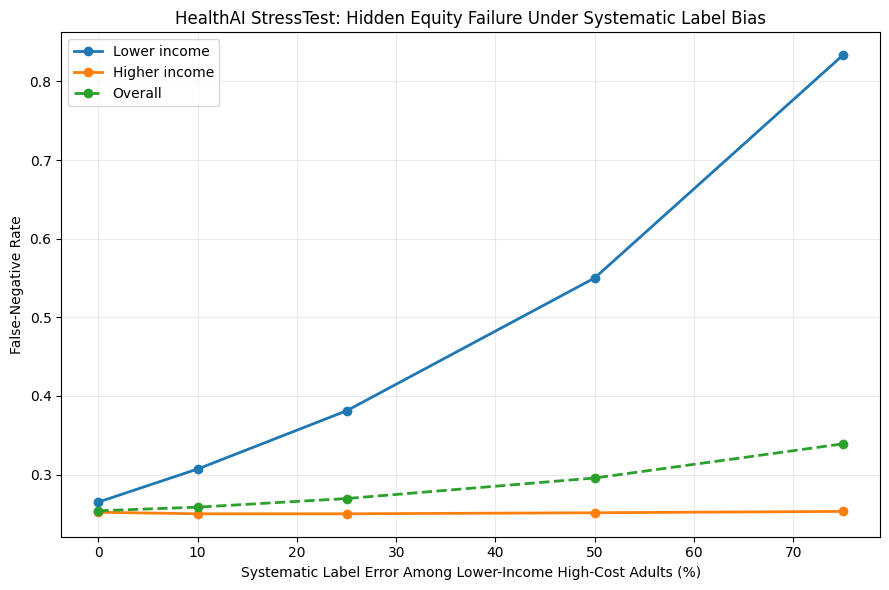

In [47]:
# ==========================================
# HealthAI StressTest
# Centerpiece Equity Failure Figure
# ==========================================

import matplotlib.pyplot as plt

plot_data = crash5_gap.copy()

x = plot_data.index * 100

plt.figure(figsize=(9, 6))

plt.plot(
    x,
    plot_data["Lower income"],
    marker="o",
    linewidth=2,
    label="Lower income"
)

plt.plot(
    x,
    plot_data["Higher income"],
    marker="o",
    linewidth=2,
    label="Higher income"
)

plt.plot(
    x,
    plot_data["Overall"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Overall"
)

plt.xlabel(
    "Systematic Label Error Among Lower-Income High-Cost Adults (%)"
)

plt.ylabel(
    "False-Negative Rate"
)

plt.title(
    "HealthAI StressTest: Hidden Equity Failure Under Systematic Label Bias"
)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

In [48]:
plt.savefig(
    "healthai_label_bias_equity_failure.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [49]:
# ==========================================
# FINAL HEALTHAI STRESSTEST SUMMARY
# ==========================================

# ---------- Baseline racial/ethnic disparity ----------

baseline_race = baseline_results[
    baseline_results["Group"] != "Overall"
].copy()

baseline_max_fnr_gap = (
    baseline_race["FNR"].max()
    - baseline_race["FNR"].min()
)


# ---------- Crash Test 1 ----------
# Poverty-data missingness among lower-income adults

crash1_low = (
    crash1_income_results[
        crash1_income_results["Income_Group"]
        == "Lower income"
    ]
    .set_index("Missingness")
)

crash1_change = (
    crash1_low.loc[1.00, "FNR"]
    - crash1_low.loc[0.00, "FNR"]
)


# ---------- Crash Test 2 ----------
# NH Asian underrepresentation

crash2_asian = (
    asian_repeat_summary
)

crash2_change = (
    crash2_asian.loc[0.10, "Mean_FNR"]
    - crash2_asian.loc[1.00, "Mean_FNR"]
)


# ---------- Crash Test 3 ----------
# Self-rated-health measurement error

crash3_baseline = crash3_mean_fnr.loc[0.00]

crash3_40 = crash3_mean_fnr.loc[0.40]

crash3_changes = (
    crash3_40 - crash3_baseline
)

# Largest worsening among racial/ethnic groups
crash3_change = crash3_changes[
    [
        "Hispanic",
        "NH Asian",
        "NH Black",
        "NH Other/Multiple",
        "NH White"
    ]
].max()


# ---------- Crash Test 4 ----------
# Insurance population shift

crash4_change = (
    shift_metrics["FNR"]
    - reference_metrics["FNR"]
)


# ---------- Crash Test 5 ----------
# Systematic label bias

crash5_baseline_lower = (
    crash5_fnr.loc[0.00, "Lower income"]
)

crash5_75_lower = (
    crash5_fnr.loc[0.75, "Lower income"]
)

crash5_change = (
    crash5_75_lower
    - crash5_baseline_lower
)

first_failure_level = crash5_gap[
    crash5_gap["FNR_Gap"] >= 0.10
].index.min()


# ---------- Final Summary ----------

final_summary = pd.DataFrame({
    "Experiment": [
        "Baseline Audit",
        "Crash 1: Poverty Missingness",
        "Crash 2: Underrepresentation",
        "Crash 3: Measurement Error",
        "Crash 4: Population Shift",
        "Crash 5: Systematic Label Bias"
    ],

    "Primary Equity Result": [
        f"{baseline_max_fnr_gap:.1%} max racial/ethnic FNR gap",
        f"{crash1_change:+.1%} lower-income FNR change",
        f"{crash2_change:+.1%} NH Asian FNR change",
        f"{crash3_change:+.1%} largest subgroup FNR change",
        f"{crash4_change:+.1%} deployment FNR change",
        f"{crash5_change:+.1%} lower-income FNR change"
    ],

    "Status": [
        "BASELINE DISPARITY",
        "NO MATERIAL ADDITIONAL DEGRADATION",
        "NO MATERIAL ADDITIONAL DEGRADATION",
        "NO MATERIAL ADDITIONAL DEGRADATION",
        "NO MATERIAL ADDITIONAL DEGRADATION",
        "EQUITY FAILURE"
    ]
})

final_summary

,Experiment,Primary Equity Result,Status
0,Baseline Audit,35.3% max racial/ethnic FNR gap,BASELINE DISPARITY
1,Crash 1: Poverty Missingness,+2.7% lower-income FNR change,NO MATERIAL ADDITIONAL DEGRADATION
2,Crash 2: Underrepresentation,+0.0% NH Asian FNR change,NO MATERIAL ADDITIONAL DEGRADATION
3,Crash 3: Measurement Error,+2.0% largest subgroup FNR change,NO MATERIAL ADDITIONAL DEGRADATION
4,Crash 4: Population Shift,+0.4% deployment FNR change,NO MATERIAL ADDITIONAL DEGRADATION
5,Crash 5: Systematic Label Bias,+56.8% lower-income FNR change,EQUITY FAILURE


In [50]:
print(
    "First tested label-error level exceeding "
    "10 percentage-point FNR gap:"
)

print(
    f"{first_failure_level:.0%}"
)

First tested label-error level exceeding 10 percentage-point FNR gap:
25%


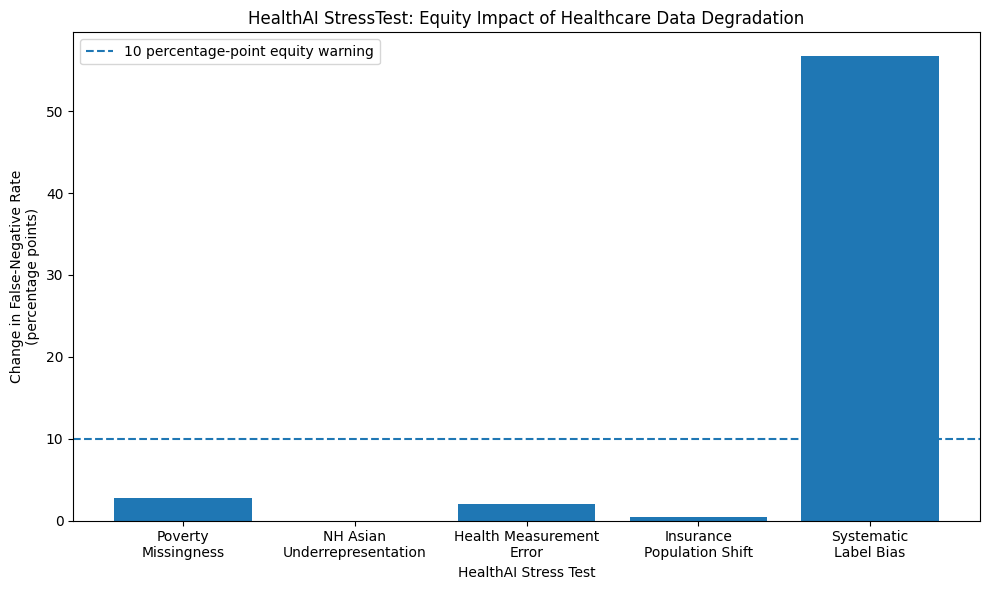

In [51]:
# ==========================================
# FINAL CRASH TEST SUMMARY FIGURE
# ==========================================

summary_plot = pd.DataFrame({
    "Stress Test": [
        "Poverty\nMissingness",
        "NH Asian\nUnderrepresentation",
        "Health Measurement\nError",
        "Insurance\nPopulation Shift",
        "Systematic\nLabel Bias"
    ],

    "FNR Change": [
        crash1_change,
        crash2_change,
        crash3_change,
        crash4_change,
        crash5_change
    ]
})

plt.figure(figsize=(10, 6))

bars = plt.bar(
    summary_plot["Stress Test"],
    summary_plot["FNR Change"] * 100
)

plt.axhline(
    10,
    linestyle="--",
    linewidth=1.5,
    label="10 percentage-point equity warning"
)

plt.ylabel(
    "Change in False-Negative Rate\n(percentage points)"
)

plt.xlabel(
    "HealthAI Stress Test"
)

plt.title(
    "HealthAI StressTest: Equity Impact of Healthcare Data Degradation"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "healthai_crash_test_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
# ==========================================
# SAVE PORTFOLIO RESULTS
# ==========================================

final_summary.to_csv(
    "healthai_final_summary.csv",
    index=False
)

baseline_results.to_csv(
    "healthai_baseline_equity_audit.csv",
    index=False
)

crash5_gap.to_csv(
    "healthai_label_bias_results.csv"
)

print("HealthAI StressTest results saved.")

HealthAI StressTest results saved.


In [53]:
final_summary = pd.DataFrame({
    "Experiment": [
        "Baseline Audit",
        "Crash 1: Poverty Missingness",
        "Crash 2: Underrepresentation",
        "Crash 3: Measurement Error",
        "Crash 4: Population Shift",
        "Crash 5: Systematic Label Bias"
    ],

    "Primary Equity Result": [
        f"{baseline_max_fnr_gap*100:.1f} pp max racial/ethnic FNR gap",
        f"{crash1_change*100:+.1f} pp lower-income FNR change",
        f"{crash2_change*100:+.1f} pp NH Asian FNR change",
        f"{crash3_change*100:+.1f} pp largest subgroup FNR change",
        f"{crash4_change*100:+.1f} pp deployment FNR change",
        f"{crash5_change*100:+.1f} pp lower-income FNR change"
    ],

    "Status": [
        "BASELINE DISPARITY",
        "NO MATERIAL ADDITIONAL DEGRADATION",
        "NO MATERIAL ADDITIONAL DEGRADATION",
        "NO MATERIAL ADDITIONAL DEGRADATION",
        "NO MATERIAL ADDITIONAL DEGRADATION",
        "EQUITY FAILURE"
    ]
})

final_summary

,Experiment,Primary Equity Result,Status
0,Baseline Audit,35.3 pp max racial/ethnic FNR gap,BASELINE DISPARITY
1,Crash 1: Poverty Missingness,+2.7 pp lower-income FNR change,NO MATERIAL ADDITIONAL DEGRADATION
2,Crash 2: Underrepresentation,+0.0 pp NH Asian FNR change,NO MATERIAL ADDITIONAL DEGRADATION
3,Crash 3: Measurement Error,+2.0 pp largest subgroup FNR change,NO MATERIAL ADDITIONAL DEGRADATION
4,Crash 4: Population Shift,+0.4 pp deployment FNR change,NO MATERIAL ADDITIONAL DEGRADATION
5,Crash 5: Systematic Label Bias,+56.8 pp lower-income FNR change,EQUITY FAILURE


In [54]:
final_summary.to_csv(
    "healthai_final_summary.csv",
    index=False
)

print("Corrected final summary saved.")

Corrected final summary saved.


In [55]:
import os

files_to_check = [
    "healthai_final_summary.csv",
    "healthai_baseline_equity_audit.csv",
    "healthai_label_bias_results.csv",
    "healthai_crash_test_summary.png",
    "healthai_label_bias_equity_failure.png"
]

for file in files_to_check:
    print(file, "✓" if os.path.exists(file) else "MISSING")

healthai_final_summary.csv ✓
healthai_baseline_equity_audit.csv ✓
healthai_label_bias_results.csv ✓
healthai_crash_test_summary.png ✓
healthai_label_bias_equity_failure.png ✓
